In [ ]:
import os

import h5py
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

from fit.fit_v7 import Fit
from fit.plot import *

from fit.get_data import *


In [ ]:
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_02_without_sweep"
results_folder = os.path.join(folder, "fit_results")

# Orders the fit files by name
fit_files = sorted(f for f in os.listdir(results_folder) if f.endswith("_fit.h5"))
print(f"Found {len(fit_files)} fit results")


In [ ]:
# --- Pick one measurement file by index ---
raw_files = sorted(f for f in os.listdir(folder) if f.endswith("esr.h5"))

# Choose which file to view
raw_file = raw_files[0]
print(f"Selected raw file: {raw_file}")

fit_file_odmr = raw_file.replace(".h5", "_odmr_fit.h5")
fit_file_B    = raw_file.replace(".h5", "_B_fit.h5")

fit_path_odmr = os.path.join(results_folder, fit_file_odmr)
fit_path_B    = os.path.join(results_folder, fit_file_B)

fit_ds_odmr = xr.load_dataset(fit_path_odmr, engine="h5netcdf")
fit_ds_B    = xr.load_dataset(fit_path_B, engine="h5netcdf")

# --- Show datasets ---
print("\n--- ODMR fit dataset ---")
print(fit_ds_odmr)

print("\n--- B-field fit dataset ---")
print(fit_ds_B)

# Load raw data (needed only for ODMR)
subset_ds, ds_ql, ds_timetrace = widefield_get_data(folder, raw_file, esr_normalized=True, ql_normalized=True)
subset_ds = subset_ds.sum(dim="blocks")

# --- Plot ODMR fit ---
plot_obj_ODMR = Plot_ODMR_2D(subset_ds, fit_ds_odmr, nitrogen=15)
plot_obj_ODMR.plot_specific_fit(x_val=25, y_val=25)

# --- Plot B-field fit ---
plot_obj_B = Plot_Hamiltonian_Parameters_2D(fit_ds_B, nitrogen=15)
plot_obj_B.plot_B_all_comp()


In [ ]:
for i, fit_file in enumerate(fit_files, start=1):
    if not fit_file.endswith("_odmr_fit.h5"):
        continue  # skip B-field files here

    print(f"[{i}/{len(fit_files)}] Plotting ODMR fit: {fit_file}")
    
    fit_path = os.path.join(results_folder, fit_file)
    fit_ds = xr.load_dataset(fit_path, engine="h5netcdf")

    # Reload raw data corresponding to this file
    raw_file = fit_file.replace("_odmr_fit.h5", ".h5")
    subset_ds, *_ = widefield_get_data(folder, raw_file, esr_normalized=True, ql_normalized=True)
    subset_ds = subset_ds.sum(dim="blocks")

    # Plot ODMR
    plot_obj_ODMR = Plot_ODMR_2D(subset_ds, fit_ds, nitrogen=15)
    plot_obj_ODMR.plot_specific_fit()
    #plot_obj_ODMR.plot_freq_2d()


In [ ]:
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_02_sweep_fit_results_diff"
results_folder = folder

# Orders the fit files by name
fit_files = sorted(f for f in os.listdir(results_folder) if f.endswith("_diff.h5"))
print(f"Found {len(fit_files)} fit results")

save_folder = os.path.join(results_folder, "B_field_plots")
os.makedirs(save_folder, exist_ok=True)

for i, fit_file in enumerate(fit_files, start=1):
    if not fit_file.endswith("_fit_diff.h5"):
        continue 

    print(f"[{i}/{len(fit_files)}] Plotting B-field fit: {fit_file}")
    
    fit_path = os.path.join(results_folder, fit_file)
    fit_ds = xr.load_dataset(fit_path, engine="h5netcdf")

    # Plot B-field components
    plot_obj_B = Plot_Hamiltonian_Parameters_2D(fit_ds, nitrogen=15)
    plot_obj_B.plot_B_all_comp()

    # # # Save the figure
    # save_path = os.path.join(save_folder, fit_file.replace("_B_fit_diff.h5", "_B_field.png"))
    # plt.savefig(save_path, dpi=300, bbox_inches="tight")
    # plt.close()  # close figure to free memory

    # print(f"Saved plot in {save_path}")


In [ ]:
folder_with = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_02_with_sweep\fit_results"
folder_without = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_02_without_sweep\fit_results"

parent_dir = os.path.dirname(os.path.dirname(folder_with))  # go two levels up
folder_diff = os.path.join(parent_dir, "fit_results_diff")
os.makedirs(folder_diff, exist_ok=True)

files_with = sorted(f for f in os.listdir(folder_with) if f.endswith("_B_fit.h5"))
files_without = sorted(f for f in os.listdir(folder_without) if f.endswith("_B_fit.h5"))

print(f"Found {len(files_with)} files WITH sweep")
print(f"Found {len(files_without)} files WITHOUT sweep")

if len(files_with) != len(files_without):
    raise ValueError("Mismatch: # of with_sweep and without_sweep files must be equal.")

for i, (f_with, f_without) in enumerate(zip(files_with, files_without), start=1):
    print(f"[{i}/{len(files_with)}] Processing {f_with} vs {f_without}")

    # Load datasets
    ds_with = xr.load_dataset(os.path.join(folder_with, f_with), engine="h5netcdf")
    ds_without = xr.load_dataset(os.path.join(folder_without, f_without), engine="h5netcdf")

    # Compute difference
    ds_diff = ds_with - ds_without

    # Save to new folder
    out_name = f_with.replace("_B_fit.h5", "_B_fit_diff.h5")
    out_path = os.path.join(folder_diff, out_name)
    ds_diff.to_netcdf(out_path, engine="h5netcdf")

    print(f"Saved diff dataset: {out_path}")


In [ ]:
import os
import imageio
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# === SETTINGS ===
results_folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_02_with_sweep\fit_results"
save_folder = os.path.join(results_folder, "B_field_gifs")
os.makedirs(save_folder, exist_ok=True)

# Load all *_B_fit.h5 files
fit_files = sorted(f for f in os.listdir(results_folder) if f.endswith("_B_fit.h5"))

# We want 4 gifs: magnitude and B-field components
components = ["zfs_b", "b_x", "b_y", "b_z"]
images = {comp: [] for comp in components}

# === BUILD FRAMES ===
for i, fit_file in enumerate(fit_files, start=1):
    fit_path = os.path.join(results_folder, fit_file)
    fit_ds = xr.load_dataset(fit_path, engine="h5netcdf")

    print(f"[{i}/{len(fit_files)}] Processing {fit_file}")

    # Extract zfs_b (Nx, Ny, 4) → magnitude, bx, by, bz
    zfs_b = fit_ds["zfs_b"].values  # (Nx, Ny, 4)

    comp_data = {
        "zfs_b": zfs_b[:, :, 0],   # Magnitude (ZFS)
        "b_x": zfs_b[:, :, 1],
        "b_y": zfs_b[:, :, 2],
        "b_z": zfs_b[:, :, 3],
    }

    # Make a plot for each component and save as frame
    for comp, data in comp_data.items():
        fig, ax = plt.subplots(figsize=(4, 4))
        cmap = sns.color_palette("mako", as_cmap=True)  # Using Seaborn crest colormap
        im = ax.imshow(data, origin="lower", cmap=cmap)
        fig.colorbar(im, ax=ax, label=comp)
        ax.set_title(f"{comp} | {fit_file}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

        # Save frame to numpy array (for GIFs)
        fig.canvas.draw()
        frame = np.array(fig.canvas.renderer.buffer_rgba())
        images[comp].append(frame)

        plt.close(fig)

# === CREATE GIFs ===
for comp, frames in images.items():
    gif_path = os.path.join(save_folder, f"{comp}.gif")
    imageio.mimsave(gif_path, frames, fps=2)  # 2 frames per second
    print(f"Saved GIF: {gif_path}")


In [ ]:
import os

import h5py
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import sys

from fit.plot import *
from fit.fit_v7 import *
from fit.get_data import *



In [ ]:
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09"
# Get all .h5 files
all_files = [f for f in os.listdir(folder) if f.endswith('esr.h5')]

for file in all_files:
    # Full file path
    file_path = os.path.join(folder, file)
    print(file)
    try:
        ds_esr, ds_ql, ds_timetrace = widefield_get_data(folder, file, ql_normalized=True, get_ql=True)

        data_ds = ds_ql.mean(dim="ql_blocks")


        plt.figure(figsize=(6, 4))
        plt.plot(data_ds.rf.values, data_ds.values, color='slateblue')
        plt.title('ESR Spectrum')
        plt.xlabel('RF Frequency (GHz)')
        plt.ylabel('Normalized PL')
        plt.axvline(x=2.87e9, color='orchid', linestyle='--', label='Zero Field Splitting (2.87 GHz)')
        plt.legend()
        plt.grid()
        plt.show()


    except Exception as e:
        print(f"Failed to process {file}: {e}")

In [ ]:
import h5py

with h5py.File(os.path.join(folder, file), 'r') as f:
    print(list(f.keys()))
    print(f['data/esr'].shape)
    print(list(f['data/esr'].dims))

In [ ]:
ds_esr, ds_ql, ds_timetrace = widefield_get_data(folder, file, ql_normalized=True)

data_ds = ds_ql.mean(dim="ql_blocks")


plt.figure(figsize=(12, 8))
plt.plot(data_ds.rf.values, data_ds.values, color='slateblue')
plt.title('ESR Spectrum')
plt.xlabel('RF Frequency (GHz)')
plt.ylabel('Normalized PL')
plt.axvline(x=2.87e9, color='orchid', linestyle='--', label='Zero Field Splitting (2.87 GHz)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import os
import h5py
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
from fit.plot import *
from fit.fit_v7 import *
from fit.get_data import *

# Set your folder path
#folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_08_25"

# Get all .h5 files
all_files = [f for f in os.listdir(folder) if f.endswith('esr.h5')]

# Dropdown widget for selecting a file
file_selector = widgets.Dropdown(
    options=all_files,
    description='Select file:',
    layout=widgets.Layout(width='50%')
)

# Define a function that runs your processing
def process_file(file):
    file_path = os.path.join(folder, file)
    print(f"Processing: {file}")
    try:
        ds_esr, ds_ql, ds_timetrace = widefield_get_data(folder, file, ql_normalized=True)
        data_ds = ds_ql.mean(dim="ql_blocks")
        plt.figure(figsize=(6, 4))
        plt.plot(data_ds.rf.values, data_ds.values, color='slateblue')
        plt.title('ESR Spectrum')
        plt.xlabel('RF Frequency (GHz)')
        plt.ylabel('Normalized PL')
        plt.axvline(x=2.87e9, color='orchid', linestyle='--', label='Zero Field Splitting (2.87 GHz)')
        plt.legend()
        plt.grid()
        plt.show()
    except Exception as e:
        print(f"Failed to process {file}: {e}")

# Use interact to bind the widget to the function
interact(process_file, file=file_selector)


In [ ]:
import os
import h5py
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
from fit.plot import *
from fit.fit_v7 import *
from fit.get_data import *

# Set your folder path
#folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_08_25"

# Get all .h5 files
all_files = [f for f in os.listdir(folder) if f.endswith('esr.h5')]

# Dropdown widget for selecting a file
file_selector = widgets.Dropdown(
    options=all_files,
    description='Select file:',
    layout=widgets.Layout(width='50%')
)

# Define a function that runs your processing
def process_file(file):
    file_path = os.path.join(folder, file)
    print(f"Processing: {file}")
    try:
        ds_esr, ds_ql, ds_timetrace = widefield_get_data(folder, file, esr_normalized=True, ql_normalized=True)
        data_ds = ds_ql.mean(dim="ql_blocks")
        #ds_ql = ds_esr.isel(x=24, y=0).sum(dim="blocks")
        ds_ql = ds_ql.sum(dim="ql_blocks")
        ds_ql.coords["rf"][0]
        fit_obj = Fit(ds_ql, nr_of_dips=8, linewidth=2.0e6)
        fit_obj.fit_odmr_data_0d()
        plot_obj = Plot_ODMR_0D(ds_ql, fit_obj.fit_result, nitrogen=15)
        plot_obj.plot_fit()
        fit_obj.fit_B_field_0d()
        print(fit_obj.fit_B_result)
    except Exception as e:
        print(f"Failed to process {file}: {e}")

# Use interact to bind the widget to the function
interact(process_file, file=file_selector)


In [ ]:
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09"
# Get all .h5 files
all_files = [f for f in os.listdir(folder) if f.endswith('esr.h5')]

for file in all_files:
    # Full file path
    file_path = os.path.join(folder, file)
    print(file)
    try:
        ds_esr, ds_timetrace = widefield_get_data(folder, file, ql_normalized=False, get_ql=False)

        print(ds_esr)

    except Exception as e:
        print(f"Failed to process {file}: {e}")

In [ ]:
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09"
fit_folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09\fit_results"

# Get all .h5 files
all_files = [f for f in os.listdir(folder) if f.endswith('esr.h5')][:1]
all_fit_files = [f for f in os.listdir(fit_folder) if f.endswith('odmr_fit.h5')][:1]

for file, fit_file in zip(all_files, all_fit_files):
    # Full file path
    file_path = os.path.join(folder, file)
    print(file)
    try:
        ds_esr, ds_ql, ds_timetrace = widefield_get_data(folder, file, esr_normalized=True, ql_normalized=False, get_ql=False, get_timetrace=False)
        print(ds_esr)
        ds_esr = ds_esr.sel(x=slice(200, 300), y=slice(200, 300))
        data_ds = ds_esr.mean(dim=["blocks", "y", "x"])
        print(data_ds)
        print("1------------------------------------------------------")
        #print(data_ds)

        fit_results = xr.load_dataset(os.path.join(fit_folder, fit_file), engine="h5netcdf")
        print(fit_results)
        plot_obj = Plot_ODMR_0D(data_ds, fit_results, nitrogen=15)
        print(1)
        plot_obj.plot_fit()

    except Exception as e:
        print(f"Failed to process {file}: {e}")

In [ ]:
subset = ds_esr.isel(blocks=0, x=250, y=250)

In [ ]:
np.set_printoptions(precision=4)

In [ ]:
subset.values

In [ ]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from fit.get_data import widefield_get_data
from fit.plot import Plot_ODMR_0D

# --- Config ---
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09"

# --- Input files ---
raw_file = "20250908_155_esr.h5"        # raw ESR data file
fit_path_odmr = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09\fit_results_seq_with_prev\20250908_155404_esr_odmr_fit.h5"  # Corresponding ODMR fit file
redchi = None  # Optional, just for title display

# --- Load ESR raw data ---
ds_esr, _, _ = widefield_get_data(
    folder, raw_file,
    esr_normalized=True, ql_normalized=False,
    get_ql=False, get_timetrace=False
)
ds_esr = ds_esr.sel(x=slice(200, 300), y=slice(200, 300))
data_ds = ds_esr.mean(dim=["blocks", "y", "x"])

# xdata is your scan axis in Hz
xdata_Hz = data_ds[data_ds.dims[0]].values
xdata_GHz = xdata_Hz / 1e9

# Load fit results
fit_results = xr.load_dataset(fit_path_odmr, engine="h5netcdf")

# Get minima indices (already stored in fit_results)
minima_indices = fit_results["minima"].values

# Convert to GHz positions
minima_freqs_GHz = xdata_GHz[minima_indices]

# Store as a new variable (don't overwrite!)
fit_results["minima_freqs"] = ("minima", minima_freqs_GHz)
print(fit_results["minima_freqs"])

# --- Plot ---
plot_obj = Plot_ODMR_0D(data_ds, fit_results, nitrogen=15)
fig, ax = plot_obj.plot_fit()
title = raw_file
if redchi is not None:
    title += f" | redchi={redchi:.2f}"
ax.set_title(title)
plt.show()


In [ ]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from fit.get_data import widefield_get_data
from fit.plot import Plot_ODMR_0D

# --- Config ---
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_19"
raw_file = "20250918_171613_esr.h5"  # Change to your desired ESR file
redchi = None  # Optional, just for title display

# --- Load ESR raw data ---
ds_esr, _, _ = widefield_get_data(
    folder, raw_file,
    esr_normalized=True, ql_normalized=False,
    get_ql=False, get_timetrace=False
)
ds_esr = ds_esr.sel(x=slice(20, 30), y=slice(20, 30))
data_ds = ds_esr.mean(dim=["blocks", "y", "x"])

# --- x-axis ---
xdata_Hz = data_ds[data_ds.dims[0]].values
xdata_GHz = xdata_Hz / 1e9

# --- Load fit results ---
fit_path_odmr = os.path.join(
    folder, "fit_results_seq_with_prev", raw_file.replace(".h5", "_odmr_fit.h5")
)
fit_results = xr.load_dataset(fit_path_odmr)
print(fit_results)
# --- Handle minima robustly ---
minima = fit_results["minima"].values

# Convert frequencies to indices if necessary
if np.issubdtype(minima.dtype, np.floating):
    # Minima are frequencies in Hz
    minima_indices = [np.argmin(np.abs(xdata_Hz - f)) for f in minima]
else:
    # Minima are already indices
    minima_indices = minima.astype(int)

# Store integer indices for plotting
fit_results["minima"] = ("minima", minima_indices)

# Store minima frequencies in GHz for reference or scatter plots
minima_freqs_GHz = np.array(xdata_Hz[minima_indices]) / 1e9
fit_results["minima_freqs"] = ("minima", minima_freqs_GHz)

print(fit_results["minima_freqs"])

# --- Plot ---
plot_obj = Plot_ODMR_0D(data_ds, fit_results, nitrogen=15)
fig, ax = plot_obj.plot_fit()
title = raw_file
if redchi is not None:
    title += f" | redchi={redchi:.2f}"
ax.set_title(title)
plt.show()


In [ ]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import datetime

results_folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09\fit_results"

fit_files = sorted(f for f in os.listdir(results_folder) if f.endswith("_B_fit.h5"))
print(f"Found {len(fit_files)} fit results")

timestamps = []
B_mag, Bx, By, Bz = [], [], [], []
B_mag_err, Bx_err, By_err, Bz_err = [], [], [], []
Redchi = []

for i, fit_file in enumerate(fit_files, start=1):
    print(f"[{i}/{len(fit_files)}] Loading B-field fit: {fit_file}")
    
    fit_path = os.path.join(results_folder, fit_file)
    fit_ds = xr.load_dataset(fit_path, engine="h5netcdf")
    #print(fit_ds)
    # Extract timestamp from filename (e.g. 20250908_155404_esr_B_fit.h5)
    match = re.search(r"(\d{8}_\d{6})", fit_file)
    if not match:
        continue
    timestamps.append(datetime.strptime(match.group(1), "%Y%m%d_%H%M%S"))

    # Extract values
    vals = fit_ds.zfs_b.values
    errs = fit_ds.zfs_b_err.values
    redchi_values = fit_ds.redchi.values

    B_mag.append(vals[0]);  Bx.append(vals[1]);  By.append(vals[2]);  Bz.append(vals[3])
    B_mag_err.append(errs[0]);  Bx_err.append(errs[1]);  By_err.append(errs[2]);  Bz_err.append(errs[3])
    Redchi.append(redchi_values)

# ---- Plot results ----
fig, axes = plt.subplots(5, 1, figsize=(10, 15), sharex=True)

# Plot B components
for ax, vals, errs, label in zip(
    axes[:4],
    [B_mag, Bx, By, Bz],
    [B_mag_err, Bx_err, By_err, Bz_err],
    [r"$|B|$ (G)", r"$B_x$ (G)", r"$B_y$ (G)", r"$B_z$ (G)"]
):
    ax.errorbar(timestamps, vals, yerr=errs, fmt=".-", capsize=3)
    ax.set_ylabel(label)

# Plot redchi
axes[4].plot(timestamps, Redchi, "o-", color="crimson")
axes[4].set_ylabel(r"$\chi^2_{red}$")

# Common X-axis label
axes[-1].set_xlabel("Timestamp")

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


In [ ]:
import os
import re
import xarray as xr
import matplotlib.pyplot as plt

# --- Paths ---
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09"
fit_folder = os.path.join(folder, "fit_results_seq_with_prev")
refit_folder = os.path.join(folder, "fit_results_refit_")
refit_folder_manual = os.path.join(folder, "fit_results_seq_with_prev")

n = 5  # number of worst fits to show

# --- Collect original ODMR fit files ---
fit_files_odmr = [f for f in os.listdir(fit_folder) if f.endswith("odmr_fit.h5")][0:130]
odmr_fit_dict = {}
for f in fit_files_odmr:
    match = re.search(r"(\d{8}_\d{6})", f)
    if match:
        odmr_fit_dict[match.group(1)] = f

# --- Collect B-field fit files ---
fit_files_B = [f for f in os.listdir(fit_folder) if f.endswith("B_fit.h5")][0:130]

# --- Build list of B-field redchi and corresponding ODMR fit ---
redchi_list = []

for fit_file in fit_files_B:
    try:
        match = re.search(r"(\d{8}_\d{6})", fit_file)
        if not match:
            continue
        timestamp = match.group(1)

        # Determine which B-field fit to use
        refit_file = f"{timestamp}_esr_B_refit.h5"
        if os.path.exists(os.path.join(refit_folder_manual, refit_file)):
            fit_path_B = os.path.join(refit_folder_manual, refit_file)
        elif os.path.exists(os.path.join(refit_folder, refit_file)):
            fit_path_B = os.path.join(refit_folder, refit_file)
        else:
            fit_path_B = os.path.join(fit_folder, fit_file)

        # Load B-field dataset
        fit_ds_B = xr.load_dataset(fit_path_B, engine="h5netcdf")
        redchi = float(fit_ds_B.redchi.values)

        # Raw ESR file
        raw_file = f"{timestamp}_esr.h5"
        if not os.path.exists(os.path.join(folder, raw_file)):
            continue

        # Determine corresponding ODMR fit file (manual > automatic > original)
        refit_odmr_file = f"{timestamp}_odmr_refit.h5"
        if os.path.exists(os.path.join(refit_folder_manual, refit_odmr_file)):
            fit_path_odmr = os.path.join(refit_folder_manual, refit_odmr_file)
        elif os.path.exists(os.path.join(refit_folder, refit_odmr_file)):
            fit_path_odmr = os.path.join(refit_folder, refit_odmr_file)
        elif timestamp in odmr_fit_dict:
            fit_path_odmr = os.path.join(fit_folder, odmr_fit_dict[timestamp])
        else:
            # Skip if no ODMR fit exists
            continue

        # Append to list: (B-field redchi, raw ESR, corresponding ODMR path)
        redchi_list.append((redchi, raw_file, fit_path_odmr))

    except Exception as e:
        print(f"Skipping {fit_file}: {e}")

# --- Sort by redchi descending (worst first) ---
redchi_list.sort(reverse=True, key=lambda x: x[0])

print(f"Found {len(redchi_list)} files with redchi values")
print("Worst fit(s):")
for r in redchi_list[:n]:
    print(r)

# --- Plot function ---
def plot_odmr_fit(raw_file, fit_path_odmr, redchi):
    try:
        # Load ESR raw data
        ds_esr, _, _ = widefield_get_data(
            folder, raw_file, esr_normalized=True, 
            ql_normalized=False, get_ql=False, get_timetrace=False
        )
        ds_esr = ds_esr.sel(x=slice(200, 300), y=slice(200, 300))
        data_ds = ds_esr.mean(dim=["blocks", "y", "x"])

        # xdata is your scan axis in Hz
        xdata_Hz = data_ds[data_ds.dims[0]].values
        xdata_GHz = xdata_Hz / 1e9

        # Load fit results
        fit_results = xr.load_dataset(fit_path_odmr, engine="h5netcdf")

        # Get minima indices (already stored in fit_results)
        minima_indices = fit_results["minima"].values

        # Convert to GHz positions
        minima_freqs_GHz = xdata_GHz[minima_indices]

        # Store as a new variable (don't overwrite!)
        fit_results["minima_freqs"] = ("minima", minima_freqs_GHz)
        # print(fit_results)
        # Plot
        plot_obj = Plot_ODMR_0D(data_ds, fit_results, nitrogen=15)
        fig, ax = plot_obj.plot_fit()
        ax.set_title(f"{raw_file} | redchi={redchi:.2f}")
        plt.show()

    except Exception as e:
        print(f"Failed to plot {raw_file}: {e}")

# --- Plot worst n fits ---
for redchi, raw_file, fit_path_odmr in redchi_list[:n]:
    print(f"Plotting {raw_file} with redchi={redchi:.2f}")
    plot_odmr_fit(raw_file, fit_path_odmr, redchi)


In [115]:
import os
import time
import xarray as xr
from fit.fit_v7 import Fit
from fit.get_data import widefield_get_data

# Path setup
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_19"
output_folder = os.path.join(folder, "fit_results_refit")
os.makedirs(output_folder, exist_ok=True)

# Sort from worst (highest redchi) to best
sorted_results = sorted(redchi_list, key=lambda x: x[0], reverse=True)

# Extract top n (redchi, raw_file, fit_file)
worst_results = sorted_results[:10]

for idx, (chi, raw_file, fit_file) in enumerate(worst_results, start=1):
    print(f"[{idx}/{len(worst_results)}] Re-fitting bad fit: {raw_file} (old redchi={chi:.2e})")

    # Full path to the raw file
    raw_path = os.path.join(folder, raw_file)
    if not os.path.exists(raw_path):
        print(f"   WARNING: raw file not found → {raw_path}")
        continue

    # Load raw ESR data
    ds_esr_norm, _, _ = widefield_get_data(
        folder,  
        raw_file,
        chunksize=10,
        esr_normalized=True,
        ql_normalized=True,
        get_ql=False
    )

    # Take the same subset as before
    subset_ds = ds_esr_norm.sel(x=slice(20, 30), y=slice(20, 30)).mean(dim=["blocks", "y", "x"])
    #print(subset_ds)
    # New fit object
    fit_obj = Fit(
        subset_ds,
        nr_of_dips=8,
        linewidth=1.0e6,
        min_distance=0,  
        nitrogen=15,
        strain=False,
        divide_zfs=False,
    )

    # ODMR fit
    start_time = time.time()
    fit_obj.fit_odmr_data_0d(p0 = None)
    print(f"   ODMR re-fit took {time.time() - start_time:.2f} seconds")
    fit_result_ODMR = fit_obj.fit_result

    out_path_odmr = os.path.join(output_folder, raw_file.replace(".h5", "_odmr_refit.h5"))
    fit_result_ODMR.to_netcdf(out_path_odmr, engine="h5netcdf")
    print(f"   Saved re-fit ODMR results → {out_path_odmr}")

    # B-field fit
    start_time = time.time()
    fit_obj.fit_B_field_0d()
    print(f"   B-field re-fit took {time.time() - start_time:.2f} seconds")
    fit_result_B = fit_obj.fit_B_result

    
    new_redchi = float(fit_result_B.redchi.values)
    print(f"   New redchi = {new_redchi:.2e} (old = {chi:.2e})")

    out_path_B = os.path.join(output_folder, raw_file.replace(".h5", "_B_refit.h5"))
    fit_result_B.to_netcdf(out_path_B, engine="h5netcdf")
    print(f"   Saved re-fit B-field results → {out_path_B}\n")



NameError: name 'redchi_list' is not defined

In [ ]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import datetime

# Paths
results_folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_19\fit_results"
#refit_folder_manual = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09\fit_results_refit_manual"
refit_folder_manual = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_18\fit_results_1"
refit_folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09\fit_results_refit_1"

# Get all B-field fit files (original)
fit_files = sorted(f for f in os.listdir(results_folder) if f.endswith("_B_fit.h5"))#[0:450]
print(f"Found {len(fit_files)} original fit results")

timestamps = []
B_mag, Bx, By, Bz = [], [], [], []
B_mag_err, Bx_err, By_err, Bz_err = [], [], [], []
Redchi = []

for i, fit_file in enumerate(fit_files, start=1):
    # Extract timestamp from filename
    match = re.search(r"(\d{8}_\d{6})", fit_file)
    if not match:
        continue
    timestamp_str = match.group(1)

    # Determine which file to load: check manual refit first, then normal refit, then original
    refit_file = f"{timestamp_str}_esr_B_refit.h5"
    if os.path.exists(os.path.join(refit_folder_manual, refit_file)):
        fit_path = os.path.join(refit_folder_manual, refit_file)
        print(f"[{i}/{len(fit_files)}] Using manual re-fit B-field: {refit_file}")
    elif os.path.exists(os.path.join(refit_folder, refit_file)):
        fit_path = os.path.join(refit_folder, refit_file)
        print(f"[{i}/{len(fit_files)}] Using re-fit B-field: {refit_file}")
    else:
        fit_path = os.path.join(results_folder, fit_file)
        print(f"[{i}/{len(fit_files)}] Using original B-field: {fit_file}")


     # Load dataset
    fit_ds = xr.load_dataset(fit_path, engine="h5netcdf")

    # Save timestamp
    timestamps.append(datetime.strptime(timestamp_str, "%Y%m%d_%H%M%S"))

    # Extract values
    vals = fit_ds.zfs_b.values
    errs = fit_ds.zfs_b_err.values
    redchi_values = fit_ds.redchi.values

    B_mag.append(vals[0]);  Bx.append(vals[1]);  By.append(vals[2]);  Bz.append(vals[3])
    B_mag_err.append(errs[0]);  Bx_err.append(errs[1]);  By_err.append(errs[2]);  Bz_err.append(errs[3])
    Redchi.append(redchi_values)

# Calculate B-field magnitude from components
B_magnitude = np.sqrt(np.array(Bx)**2 + np.array(By)**2 + np.array(Bz)**2)

# Calculate magnitude error using error propagation
B_magnitude_err = np.sqrt(
    (np.array(Bx) * np.array(Bx_err))**2 + 
    (np.array(By) * np.array(By_err))**2 + 
    (np.array(Bz) * np.array(Bz_err))**2
) / B_magnitude

# ---- Plot results ----
fig, axes = plt.subplots(6, 1, figsize=(10, 18), sharex=True)

# Plot B components
for ax, vals, errs, label in zip(
    axes[:4],
    [B_mag, Bx, By, Bz],
    [B_mag_err, Bx_err, By_err, Bz_err],
    [r"$zfs (Hz)$", r"$B_x$ (G)", r"$B_y$ (G)", r"$B_z$ (G)"]
):
    ax.errorbar(timestamps, vals, yerr=errs, fmt="o-", capsize=3)
    ax.set_ylabel(label)

# Plot B-field magnitude
axes[4].errorbar(timestamps, B_magnitude, yerr=B_magnitude_err, fmt="o-", capsize=3, color="slateblue")
axes[4].set_ylabel(r"$|B|$ (G)")

# Plot redchi
axes[5].plot(timestamps, Redchi, "o-", color="red")
axes[5].set_ylabel(r"$\chi^2_{red}$")

# Common X-axis label
axes[-1].set_xlabel("Timestamp")

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

Found 398 original fit results
[1/398] Using original B-field: 20250918_171206_esr_B_fit.h5
[2/398] Using original B-field: 20250918_171328_esr_B_fit.h5
[3/398] Using original B-field: 20250918_171451_esr_B_fit.h5
[4/398] Using original B-field: 20250918_171613_esr_B_fit.h5
[5/398] Using original B-field: 20250918_171736_esr_B_fit.h5
[6/398] Using original B-field: 20250918_171858_esr_B_fit.h5
[7/398] Using original B-field: 20250918_172026_esr_B_fit.h5
[8/398] Using original B-field: 20250918_172149_esr_B_fit.h5
[9/398] Using original B-field: 20250918_172312_esr_B_fit.h5
[10/398] Using original B-field: 20250918_172434_esr_B_fit.h5
[11/398] Using original B-field: 20250918_172557_esr_B_fit.h5
[12/398] Using original B-field: 20250918_172719_esr_B_fit.h5
[13/398] Using original B-field: 20250918_172842_esr_B_fit.h5
[14/398] Using original B-field: 20250918_173005_esr_B_fit.h5
[15/398] Using original B-field: 20250918_173128_esr_B_fit.h5
[16/398] Using original B-field: 20250918_173250

TypeError: bad operand type for abs(): 'list'

In [ ]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from fit.get_data import widefield_get_data
from fit.plot import Plot_ODMR_0D

# --- Config ---
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09"

# --- Input files ---
raw_file = "20250908_160208_esr.h5"        # Your raw ESR data file
#fit_path_odmr = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09\fit_results_refit_manual\20250908_172218_esr_odmr_refit.h5"  # Corresponding ODMR fit file
fit_path_odmr = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09\fit_results_seq_with_prev\20250908_160208_esr_odmr_fit.h5"
redchi = None  # Optional, just for title display

# --- Load ESR raw data ---
ds_esr, _, _ = widefield_get_data(
    folder, raw_file,
    esr_normalized=True, ql_normalized=False,
    get_ql=False, get_timetrace=False
)
ds_esr = ds_esr.sel(x=slice(200, 300), y=slice(200, 300))
data_ds = ds_esr.mean(dim=["blocks", "y", "x"])

# Convert minima frequencies to indices
xdata = data_ds[data_ds.dims[0]].values
# Load the fit results
fit_results = xr.load_dataset(fit_path_odmr)

fit_results["minima"] = ("nr_of_minima", [int(np.argmin(np.abs(xdata - f))) for f in fit_results.minima.values])

# --- Plot ---
plot_obj = Plot_ODMR_0D(data_ds, fit_results, nitrogen=15)
fig, ax = plot_obj.plot_fit()
title = raw_file
if redchi is not None:
    title += f" | redchi={redchi:.2f}"
ax.set_title(title)
plt.show()



In [ ]:
import os
import re
import xarray as xr
import matplotlib.pyplot as plt

# --- Paths ---
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09"
fit_folder = os.path.join(folder, "fit_results")
refit_folder = os.path.join(folder, "fit_results_refit")

n = 5  # number of worst fits to show

# --- Collect ODMR fit files ---
fit_files_odmr = [f for f in os.listdir(fit_folder) if f.endswith("odmr_fit.h5")][0:450]
odmr_fit_dict = {}
for f in fit_files_odmr:
    match = re.search(r"(\d{8}_\d{6})", f)
    if match:
        odmr_fit_dict[match.group(1)] = f

# --- Collect B-field fit files ---
fit_files_B = [f for f in os.listdir(fit_folder) if f.endswith("B_fit.h5")][0:450]

redchi_list = []

for fit_file in fit_files_B:
    try:
        # Extract timestamp
        match = re.search(r"(\d{8}_\d{6})", fit_file)
        if not match:
            continue
        timestamp = match.group(1)

        # Prefer re-fit if exists
        refit_file = f"{timestamp}_esr_B_refit.h5"
        if os.path.exists(os.path.join(refit_folder, refit_file)):
            fit_path = os.path.join(refit_folder, refit_file)
            print(f"Using re-fit B-field: {refit_file}")
        else:
            fit_path = os.path.join(fit_folder, fit_file)
            print(f"Using original B-field: {fit_file}")

        # Load dataset
        fit_ds = xr.load_dataset(fit_path, engine="h5netcdf")

        # Get redchi
        redchi = fit_ds.redchi.values.item()

        # Corresponding raw ESR file
        raw_file = f"{timestamp}_esr.h5"
        if not os.path.exists(os.path.join(folder, raw_file)):
            continue

        # Corresponding ODMR fit file (still from original fit folder)
        if timestamp not in odmr_fit_dict:
            continue
        odmr_fit_file = odmr_fit_dict[timestamp]

        redchi_list.append((redchi, raw_file, odmr_fit_file))

    except Exception as e:
        print(f"Skipping {fit_file}: {e}")

# --- Sort by redchi descending ---
redchi_list.sort(reverse=True, key=lambda x: x[0])

print(f"Found {len(redchi_list)} files with redchi values")
print("Worst fit(s):")
for r in redchi_list[:n]:
    print(r)

# --- Sort by timestamp for neighbor selection ---
redchi_list_by_time = sorted(redchi_list, key=lambda x: x[1])
timestamps = [x[1] for x in redchi_list_by_time]

# --- Function to get neighboring files ---
def get_neighbors(raw_file, timestamps):
    idx = timestamps.index(raw_file)
    prev_file = timestamps[idx - 1] if idx > 0 else None
    next_file = timestamps[idx + 1] if idx < len(timestamps) - 1 else None
    return prev_file, next_file

# --- Plot function ---
def plot_odmr_fit(raw_file, fit_file, redchi):
    try:
        # Load ESR raw data
        ds_esr, ds_ql, ds_timetrace = widefield_get_data(
            folder, raw_file, esr_normalized=True,
            ql_normalized=False, get_ql=False, get_timetrace=False
        )
        ds_esr = ds_esr.sel(x=slice(200, 300), y=slice(200, 300))
        data_ds = ds_esr.mean(dim=["blocks", "y", "x"])

        # Load ODMR fit (from fit_results, not refit)
        fit_results = xr.load_dataset(os.path.join(fit_folder, fit_file), engine="h5netcdf")

        # Plot
        plot_obj = Plot_ODMR_0D(data_ds, fit_results, nitrogen=15)
        fig, ax = plot_obj.plot_fit()
        if redchi is not None:
            ax.set_title(f"{raw_file} | redchi={redchi:.2f}")
        else:
            ax.set_title(f"{raw_file} | neighbor measurement")
        plt.show()

    except Exception as e:
        print(f"Failed to plot {raw_file}: {e}")

# --- Plot worst fits with neighbors ---
for redchi, raw_file, fit_file in redchi_list[:n]:
    print(f"\nPlotting worst fit: {raw_file} | redchi={redchi:.2f}")
    
    prev_file, next_file = get_neighbors(raw_file, timestamps)

    # Plot previous measurement if exists
    if prev_file:
        prev_fit = [f for r, f, odmr in redchi_list if f == prev_file][0]
        print(f"Plotting previous measurement: {prev_file}")
        plot_odmr_fit(prev_file, prev_fit, redchi=None)

    # Plot current worst measurement
    plot_odmr_fit(raw_file, fit_file, redchi)

    # Plot next measurement if exists
    if next_file:
        next_fit = [f for r, f, odmr in redchi_list if f == next_file][0]
        print(f"Plotting next measurement: {next_file}")
        plot_odmr_fit(next_file, next_fit, redchi=None)


In [ ]:
import os
import re
import xarray as xr
import matplotlib.pyplot as plt

# --- Paths ---
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_09"
fit_folder = os.path.join(folder, "fit_results")
refit_folder = os.path.join(folder, "fit_results_refit")
refit_folder_manual = os.path.join(folder, "fit_results_refit_manual")

n = 5  # number of worst fits to show

# --- Collect ODMR fit files ---
fit_files_odmr = [f for f in os.listdir(fit_folder) if f.endswith("odmr_fit.h5")][0:450]
odmr_fit_dict = {}
for f in fit_files_odmr:
    match = re.search(r"(\d{8}_\d{6})", f)
    if match:
        odmr_fit_dict[match.group(1)] = f

# --- Collect B-field fit files ---
fit_files_B = [f for f in os.listdir(fit_folder) if f.endswith("B_fit.h5")][0:450]

redchi_list = []

for fit_file in fit_files_B:
    try:
        # Extract timestamp
        match = re.search(r"(\d{8}_\d{6})", fit_file)
        if not match:
            continue
        timestamp = match.group(1)

        # Prefer re-fit if exists
        refit_file = f"{timestamp}_esr_B_refit.h5"

        if os.path.exists(os.path.join(refit_folder_manual, refit_file)):
            fit_path = os.path.join(refit_folder_manual, refit_file)
            print(f"Using re-fit B-field: {refit_file}")
        elif os.path.exists(os.path.join(refit_folder, refit_file)):
            fit_path = os.path.join(refit_folder, refit_file)
            print(f"Using re-fit B-field: {refit_file}")
        else:
            fit_path = os.path.join(fit_folder, fit_file)
            print(f"Using original B-field: {fit_file}")

        # Load dataset
        fit_ds = xr.load_dataset(fit_path, engine="h5netcdf")

        # Get redchi
        redchi = fit_ds.redchi.values.item()

        # Corresponding raw ESR file
        raw_file = f"{timestamp}_esr.h5"
        if not os.path.exists(os.path.join(folder, raw_file)):
            continue

        # Corresponding ODMR fit file (still from original fit folder)
        if timestamp not in odmr_fit_dict:
            continue
        odmr_fit_file = odmr_fit_dict[timestamp]

        redchi_list.append((redchi, raw_file, odmr_fit_file))

    except Exception as e:
        print(f"Skipping {fit_file}: {e}")

# --- Sort by redchi descending ---
redchi_list.sort(reverse=True, key=lambda x: x[0])

print(f"Found {len(redchi_list)} files with redchi values")
print("Worst fit(s):")
for r in redchi_list[:n]:
    print(r)

# --- Plot function ---
def plot_odmr_fit(raw_file, fit_file, redchi):
    try:
        # Load ESR raw data
        ds_esr, ds_ql, ds_timetrace = widefield_get_data(
            folder, raw_file, esr_normalized=True, 
            ql_normalized=False, get_ql=False, get_timetrace=False
        )
        ds_esr = ds_esr.sel(x=slice(200, 300), y=slice(200, 300))
        data_ds = ds_esr.mean(dim=["blocks", "y", "x"])

        # Load ODMR fit (from fit_results, not refit)
        fit_results = xr.load_dataset(os.path.join(fit_folder, fit_file), engine="h5netcdf")

        # Plot
        plot_obj = Plot_ODMR_0D(data_ds, fit_results, nitrogen=15)
        fig, ax = plot_obj.plot_fit()
        ax.set_title(f"{raw_file} | redchi={redchi:.2f}")
        plt.show()

    except Exception as e:
        print(f"Failed to plot {raw_file}: {e}")

# --- Plot worst n fits + neighbors ---
for idx, (redchi, raw_file, fit_file) in enumerate(redchi_list[:n]):
    print(f"\n[{idx+1}/{n}] Plotting worst redchi fit: {raw_file} with redchi={redchi:.2f}")
    plot_odmr_fit(raw_file, fit_file, redchi)

    # Plot previous neighbor if available
    if idx > 0:
        prev_redchi, prev_raw, prev_fit = redchi_list[idx - 1]
        print(f"   Also plotting previous neighbor: {prev_raw} with redchi={prev_redchi:.2f}")
        plot_odmr_fit(prev_raw, prev_fit, prev_redchi)

    # Plot next neighbor if available
    if idx < len(redchi_list) - 1:
        next_redchi, next_raw, next_fit = redchi_list[idx + 1]
        print(f"   Also plotting next neighbor: {next_raw} with redchi={next_redchi:.2f}")
        plot_odmr_fit(next_raw, next_fit, next_redchi)


Found 98 sequential fit results
[1/98] Loading sequential B-field: 20250918_171451_esr_B_fit.h5
[2/98] Loading sequential B-field: 20250918_171613_esr_B_fit.h5
[3/98] Loading sequential B-field: 20250918_171736_esr_B_fit.h5
[4/98] Loading sequential B-field: 20250918_171858_esr_B_fit.h5
[5/98] Loading sequential B-field: 20250918_172026_esr_B_fit.h5
[6/98] Loading sequential B-field: 20250918_172149_esr_B_fit.h5
[7/98] Loading sequential B-field: 20250918_172312_esr_B_fit.h5
[8/98] Loading sequential B-field: 20250918_172434_esr_B_fit.h5
[9/98] Loading sequential B-field: 20250918_172557_esr_B_fit.h5
[10/98] Loading sequential B-field: 20250918_172719_esr_B_fit.h5
[11/98] Loading sequential B-field: 20250918_172842_esr_B_fit.h5
[12/98] Loading sequential B-field: 20250918_173005_esr_B_fit.h5
[13/98] Loading sequential B-field: 20250918_173128_esr_B_fit.h5
[14/98] Loading sequential B-field: 20250918_173250_esr_B_fit.h5
[15/98] Loading sequential B-field: 20250918_173413_esr_B_fit.h5
[1

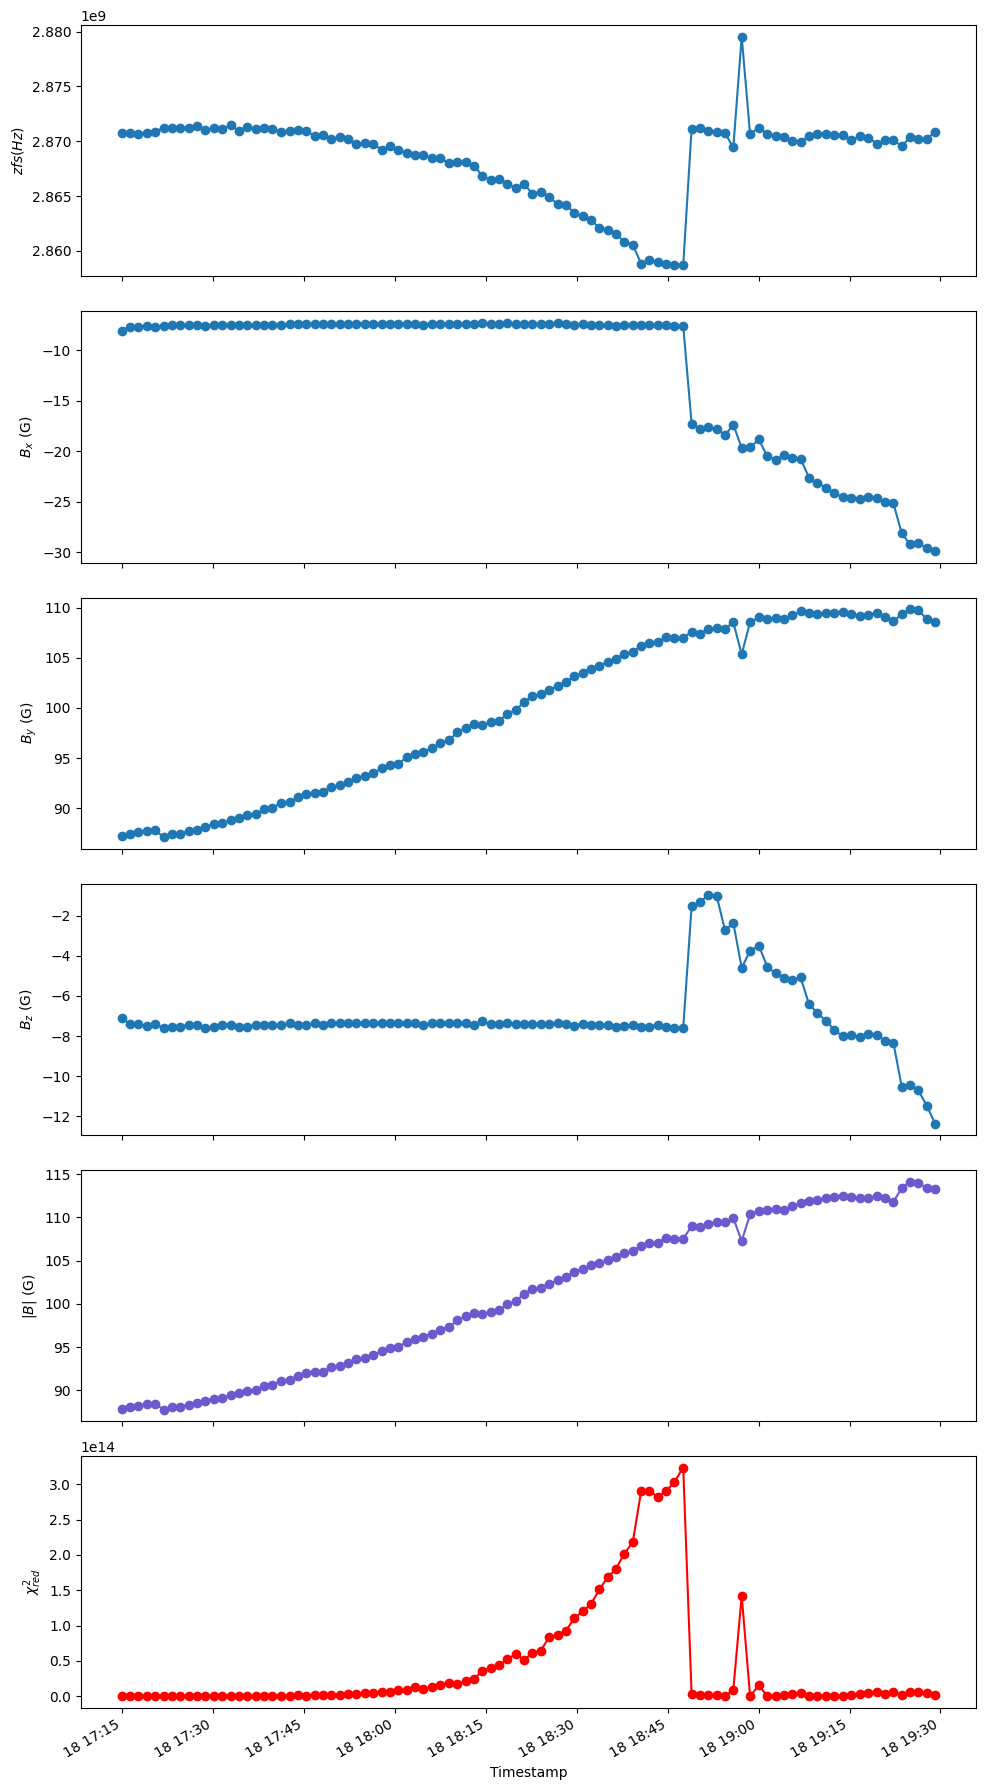

In [114]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import datetime

# Paths -> updated to sequential results folder
seq_folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_19\fit_results_seq_with_prev"

# Get all B-field fit files in the sequential folder
fit_files = sorted(f for f in os.listdir(seq_folder) if f.endswith("_B_fit.h5"))[2:100]
print(f"Found {len(fit_files)} sequential fit results")

timestamps = []
B_mag, Bx, By, Bz = [], [], [], []
B_mag_err, Bx_err, By_err, Bz_err = [], [], [], []
Redchi = []

for i, fit_file in enumerate(fit_files, start=1):
    # Extract timestamp from filename
    match = re.search(r"(\d{8}_\d{6})", fit_file)
    if not match:
        continue
    timestamp_str = match.group(1)

    fit_path = os.path.join(seq_folder, fit_file)
    print(f"[{i}/{len(fit_files)}] Loading sequential B-field: {fit_file}")

    # Load dataset
    fit_ds = xr.load_dataset(fit_path, engine="h5netcdf")

    # Save timestamp
    timestamps.append(datetime.strptime(timestamp_str, "%Y%m%d_%H%M%S"))

    # Extract values
    vals = fit_ds.zfs_b.values
    errs = fit_ds.zfs_b_err.values
    redchi_values = fit_ds.redchi.values

    B_mag.append(vals[0]);  Bx.append(vals[1]);  By.append(vals[2]);  Bz.append(vals[3])
    B_mag_err.append(errs[0]);  Bx_err.append(errs[1]);  By_err.append(errs[2]);  Bz_err.append(errs[3])
    Redchi.append(redchi_values)

# Calculate B-field magnitude from components
B_magnitude = np.sqrt(np.array(Bx)**2 + np.array(By)**2 + np.array(Bz)**2)

# Calculate magnitude error using error propagation
B_magnitude_err = np.sqrt(
    (np.array(Bx) * np.array(Bx_err))**2 + 
    (np.array(By) * np.array(By_err))**2 + 
    (np.array(Bz) * np.array(Bz_err))**2
) / B_magnitude

# ---- Plot results ----
fig, axes = plt.subplots(6, 1, figsize=(10, 18), sharex=True)

# Plot B components
for ax, vals, errs, label in zip(
    axes[:4],
    [B_mag, Bx, By, Bz],
    [B_mag_err, Bx_err, By_err, Bz_err],
    [r"$zfs (Hz)$", r"$B_x$ (G)", r"$B_y$ (G)", r"$B_z$ (G)"]
):
    ax.errorbar(timestamps, vals, yerr=errs, fmt="o-", capsize=3)
    ax.set_ylabel(label)

# Plot B-field magnitude
axes[4].errorbar(timestamps, B_magnitude, yerr=B_magnitude_err, fmt="o-", capsize=3, color="slateblue")
axes[4].set_ylabel(r"$|B|$ (G)")

# Plot redchi
axes[5].plot(timestamps, Redchi, "o-", color="red")
axes[5].set_ylabel(r"$\chi^2_{red}$")

# Common X-axis label
axes[-1].set_xlabel("Timestamp")

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

Found 24 ESR files, plotting first 100


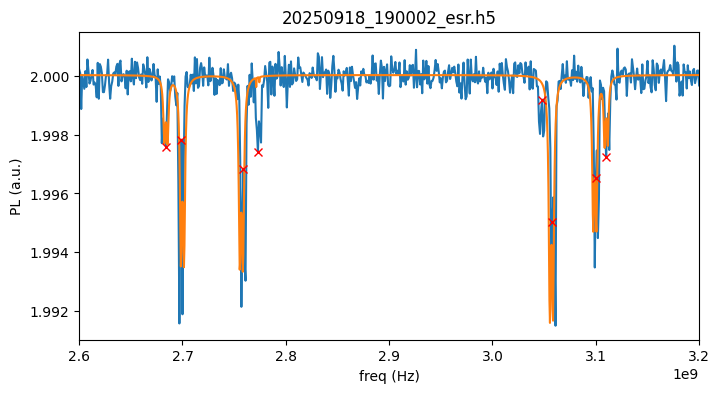

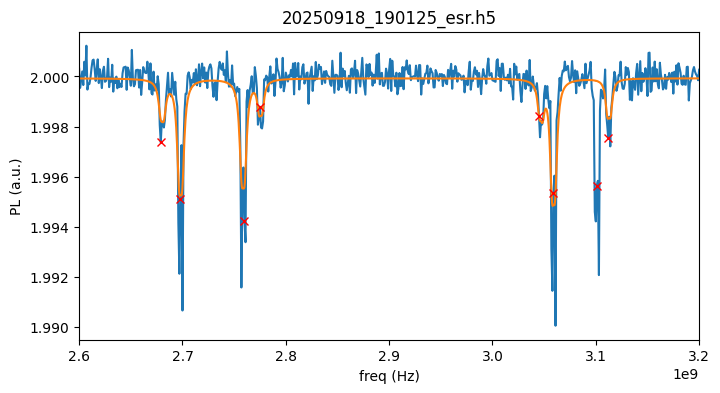

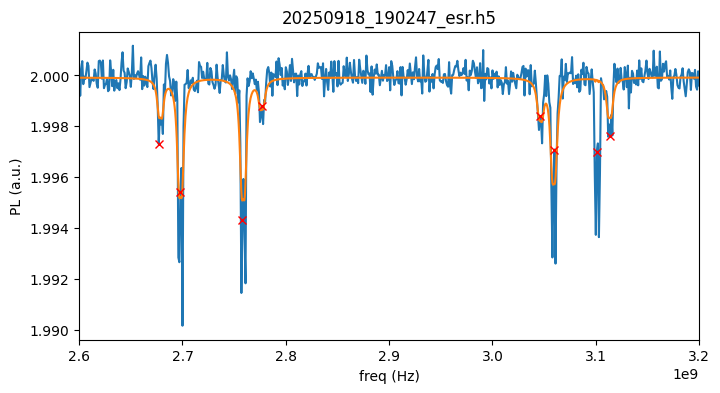

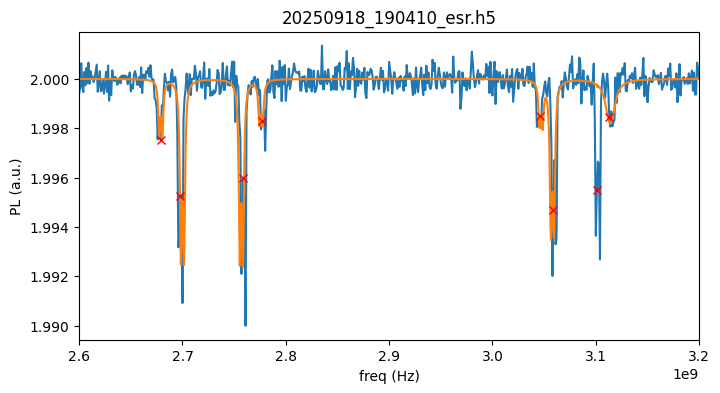

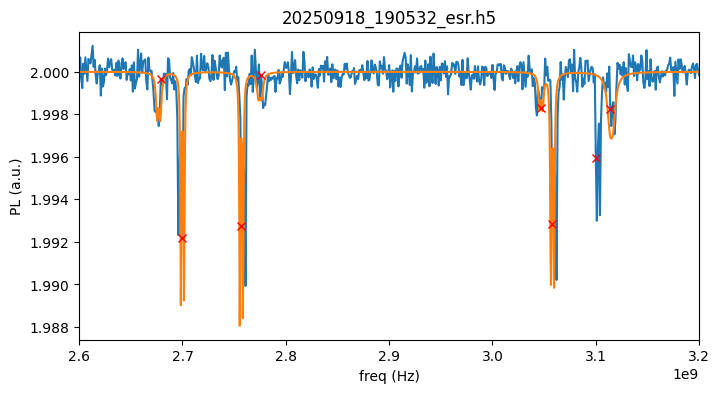

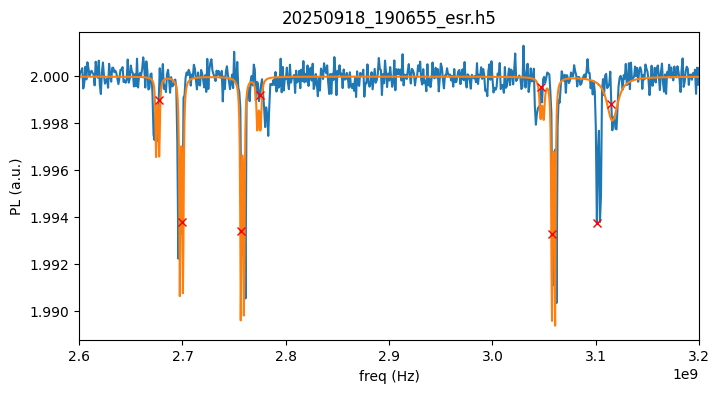

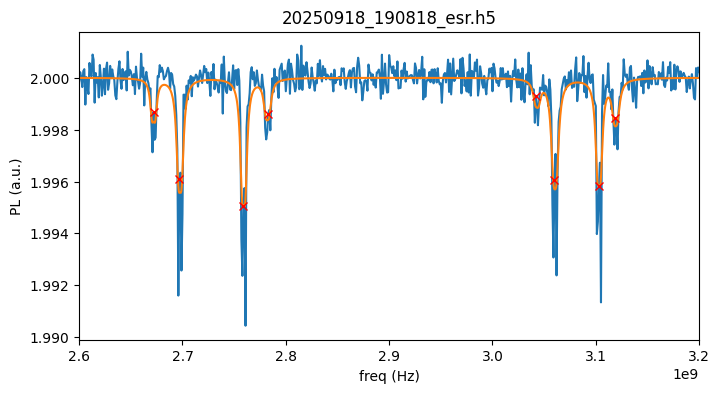

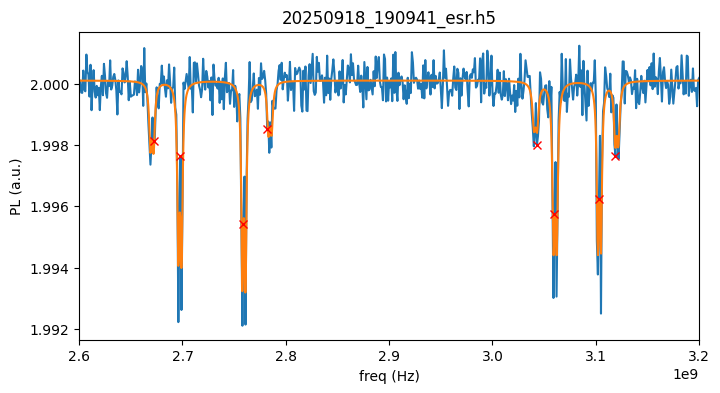

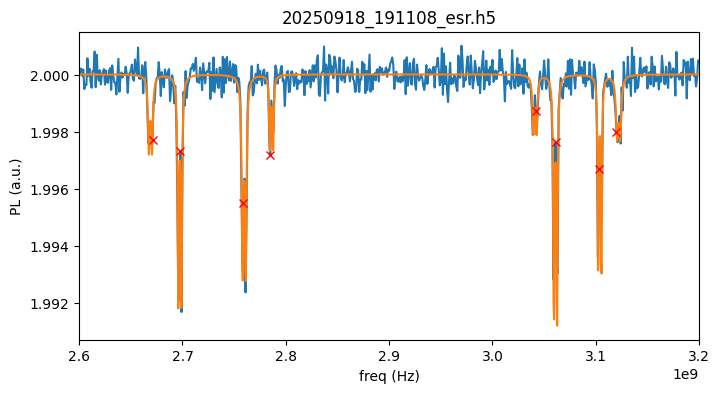

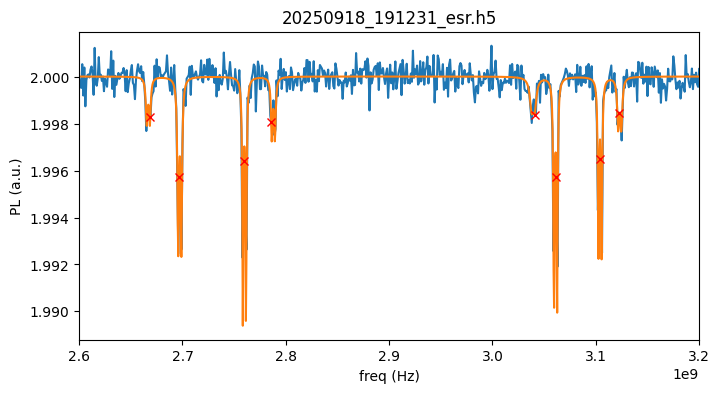

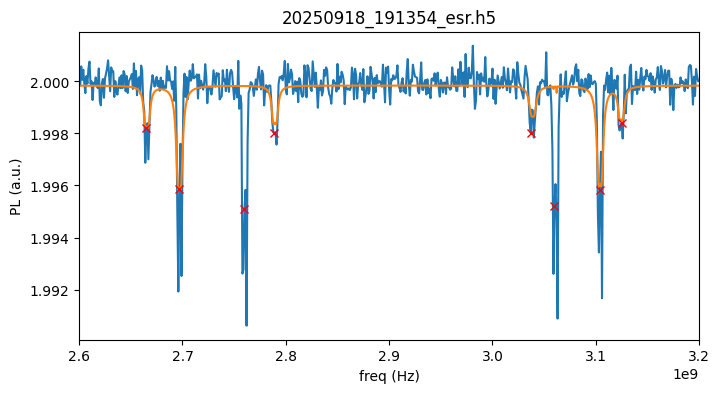

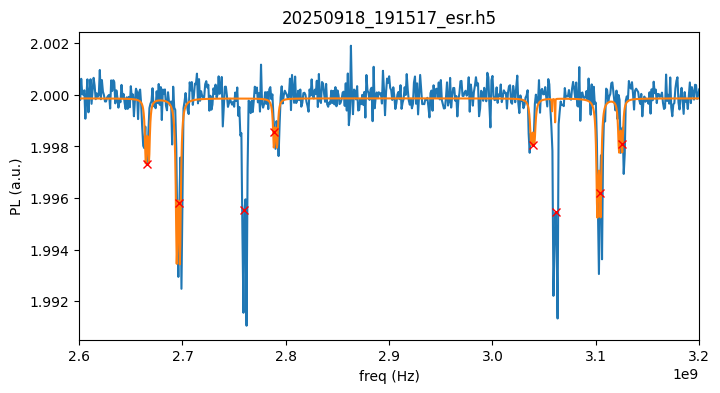

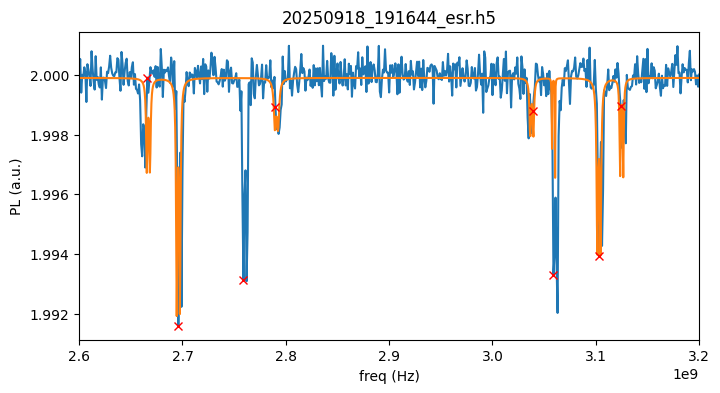

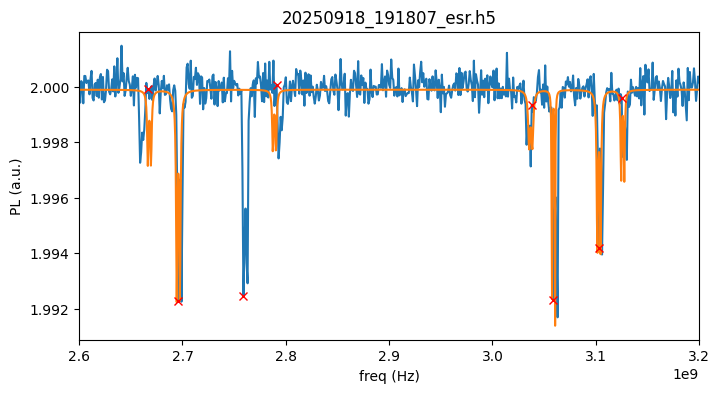

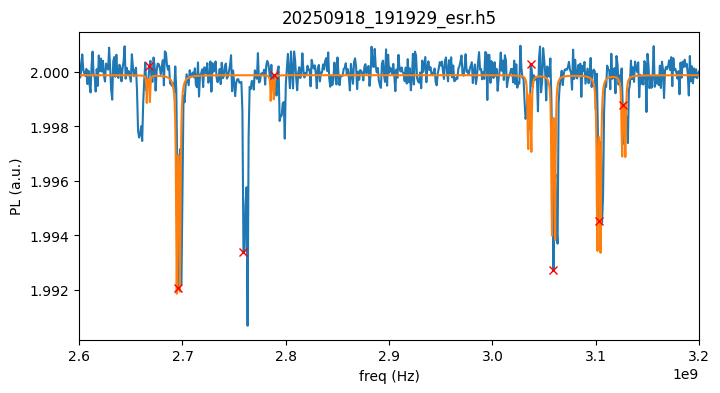

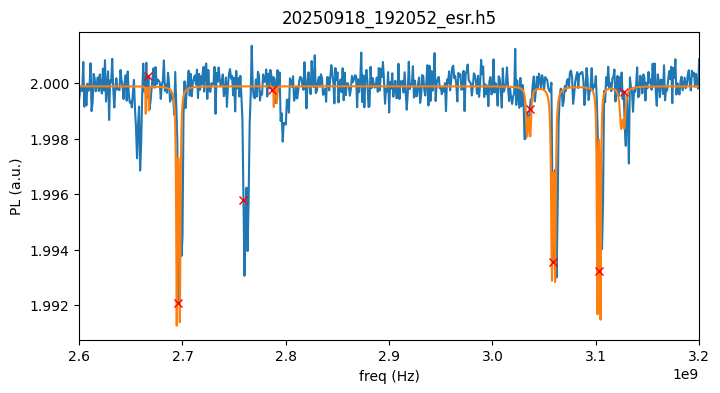

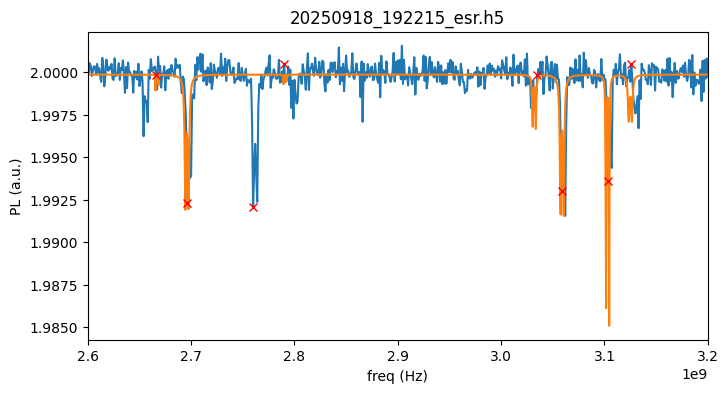

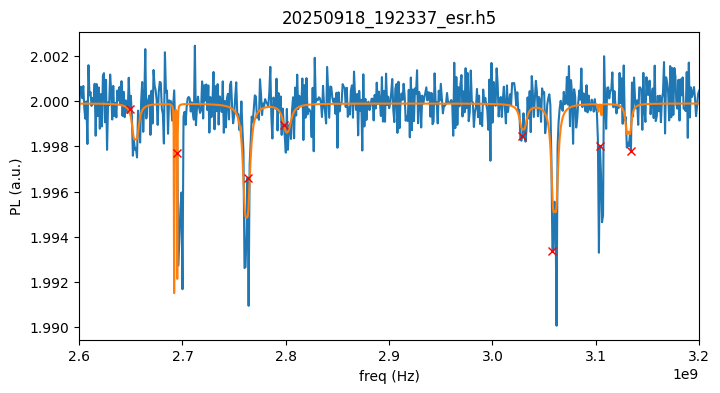

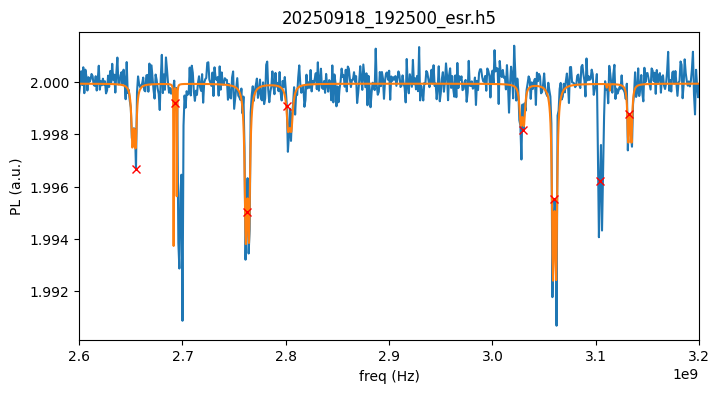

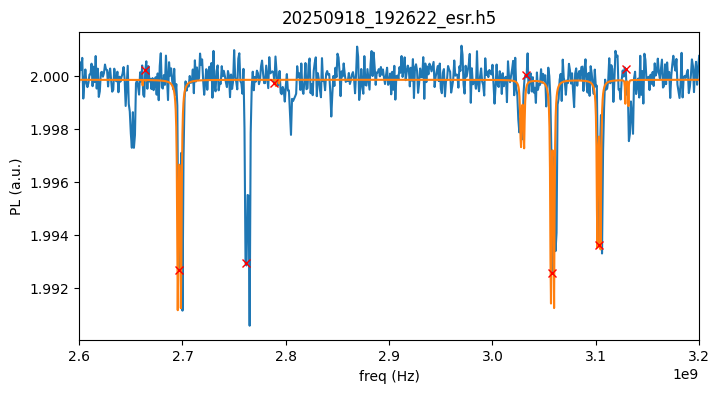

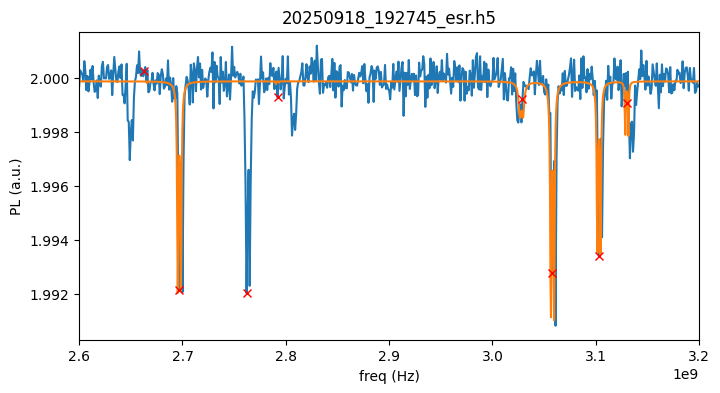

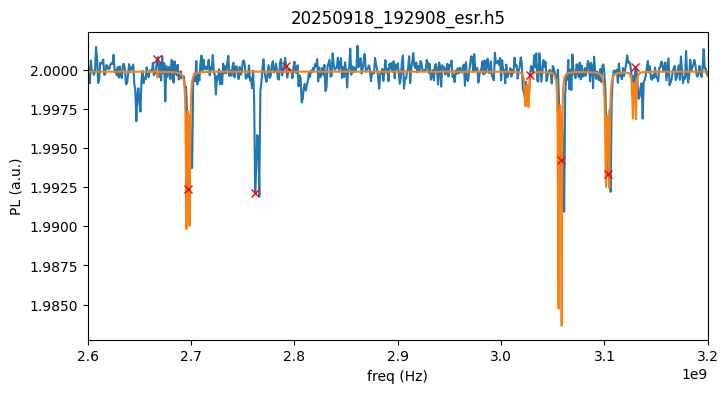

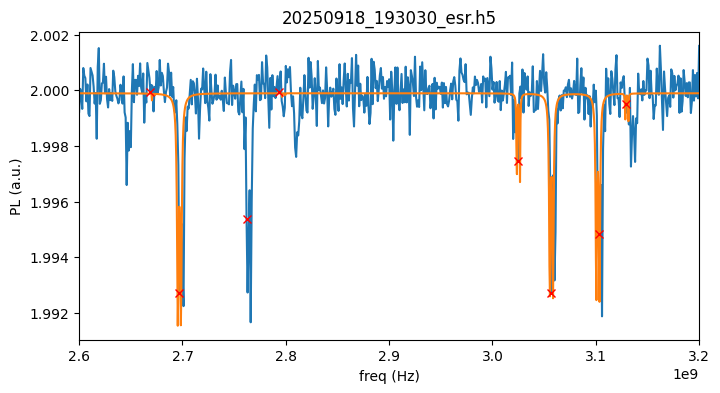

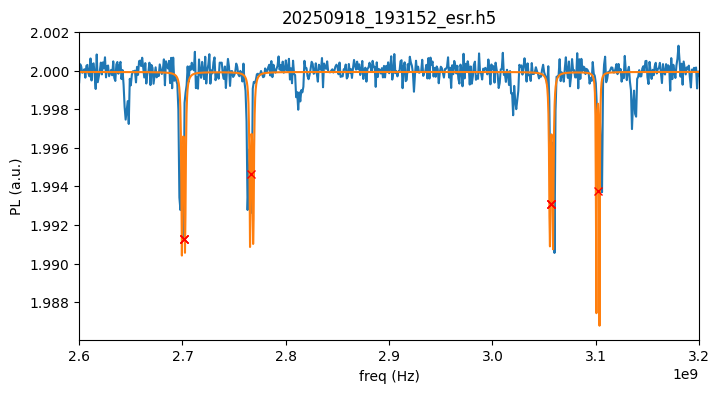

In [112]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from fit.get_data import widefield_get_data
from fit.plot import Plot_ODMR_0D

# --- Config ---
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_19"
fit_folder = os.path.join(folder, "fit_results_seq_with_prev")

n = 100 # number of first ESR files to plot

# --- Collect ESR raw files ---
raw_files = sorted([f for f in os.listdir(folder) if f.endswith("_esr.h5")])[2:]
raw_files = raw_files[76:n]  # only take the first n

print(f"Found {len(raw_files)} ESR files, plotting first {n}")

for raw_file in raw_files:
    try:
        # --- Load ESR raw data ---
        ds_esr, _, _ = widefield_get_data(
            folder, raw_file,
            esr_normalized=True, ql_normalized=False,
            get_ql=False, get_timetrace=False
        )
        ds_esr = ds_esr.sel(x=slice(20, 30), y=slice(20, 30))
        data_ds = ds_esr.mean(dim=["blocks", "y", "x"])

        # --- x-axis ---
        xdata_Hz = data_ds[data_ds.dims[0]].values
        xdata_GHz = xdata_Hz / 1e9

        # --- Load fit results ---
        fit_path_odmr = os.path.join(fit_folder, raw_file.replace(".h5", "_odmr_fit.h5"))
        if not os.path.exists(fit_path_odmr):
            print(f"Skipping {raw_file}: no fit file found")
            continue

        fit_results = xr.load_dataset(fit_path_odmr)

        # --- Handle minima: assume they are always frequencies in Hz ---
        minima_Hz = fit_results["minima"].values
        
        # Convert frequencies to array indices
        minima_indices = []
        minima_freqs_GHz = []
        
        for freq_Hz in minima_Hz:
            if freq_Hz > 1e8:  # If it's a realistic frequency (> 100 MHz)
                idx = np.argmin(np.abs(xdata_Hz - freq_Hz))
                minima_indices.append(idx)
                minima_freqs_GHz.append(freq_Hz / 1e9)
            else:
                # If it's already an index (shouldn't happen, but safety check)
                idx = int(freq_Hz)
                if 0 <= idx < len(xdata_Hz):
                    minima_indices.append(idx)
                    minima_freqs_GHz.append(xdata_Hz[idx] / 1e9)
                else:
                    print(f"Warning: invalid index {idx} in {raw_file}")
                    continue

        # --- Create new dataset to avoid merge conflicts ---
        fit_results_updated = xr.Dataset({
            "popt": fit_results["popt"],
            "perr": fit_results["perr"],
            "redchi": fit_results["redchi"],
            "minima": ("minima", minima_indices),  # Now these are proper indices
            "minima_freqs": ("minima", minima_freqs_GHz)
        })

        # --- Plot ---
        plot_obj = Plot_ODMR_0D(data_ds, fit_results_updated, nitrogen=15)
        fig, ax = plot_obj.plot_fit()
        ax.set_title(raw_file)
        plt.show()

    except Exception as e:
        print(f"Failed to plot {raw_file}: {e}")
        import traceback
        traceback.print_exc()

In [ ]:
# --- Vector Field Analysis of SEM Polepiece Scan ---

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

# Convert lists from previous block into numpy arrays
Bx_arr = np.array(Bx)
By_arr = np.array(By)
Bz_arr = np.array(Bz)
timestamps_arr = np.array(timestamps)

# --- 1) Normalize vectors: field direction ---
Bnorm = np.sqrt(Bx_arr**2 + By_arr**2 + Bz_arr**2)
Bx_hat, By_hat, Bz_hat = Bx_arr / Bnorm, By_arr / Bnorm, Bz_arr / Bnorm

# --- 2) 3D parametric plot of field direction ---
colors = cm.viridis(np.linspace(0, 1, len(Bx_hat)))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Plot trajectory with gradient color
for i in range(len(Bx_hat) - 1):
    ax.plot(Bx_hat[i:i+2], By_hat[i:i+2], Bz_hat[i:i+2],
            color=colors[i], lw=2)

# Optional arrows (direction of scan)
step = max(1, len(Bx_hat)//15)
ax.quiver(Bx_hat[::step], By_hat[::step], Bz_hat[::step],
          np.diff(Bx_hat[::step], append=Bx_hat[-1]),
          np.diff(By_hat[::step], append=By_hat[-1]),
          np.diff(Bz_hat[::step], append=Bz_hat[-1]),
          length=0.1, normalize=True, color="red")

ax.set_xlabel(r"$\hat{B}_x$")
ax.set_ylabel(r"$\hat{B}_y$")
ax.set_zlabel(r"$\hat{B}_z$")
ax.set_title("Magnetic Field Direction Along Polepiece Scan")
plt.show()

# --- 3) 2D projections for easier visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(Bx_hat, By_hat, "-o", markersize=2)
axes[0].set_xlabel(r"$\hat{B}_x$")
axes[0].set_ylabel(r"$\hat{B}_y$")
axes[0].set_title("Projection: Bx vs By")

axes[1].plot(By_hat, Bz_hat, "-o", markersize=2)
axes[1].set_xlabel(r"$\hat{B}_y$")
axes[1].set_ylabel(r"$\hat{B}_z$")
axes[1].set_title("Projection: By vs Bz")

axes[2].plot(Bx_hat, Bz_hat, "-o", markersize=2)
axes[2].set_xlabel(r"$\hat{B}_x$")
axes[2].set_ylabel(r"$\hat{B}_z$")
axes[2].set_title("Projection: Bx vs Bz")

fig.tight_layout()
plt.show()

# --- 4) Field gradient analysis ---
# Approximate derivative wrt scan progression (index ~ position)
dBx = np.gradient(Bx_arr)
dBy = np.gradient(By_arr)
dBz = np.gradient(Bz_arr)
dBmag = np.gradient(Bnorm)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(timestamps_arr, dBx, label="dBx/dy")
ax.plot(timestamps_arr, dBy, label="dBy/dy")
ax.plot(timestamps_arr, dBz, label="dBz/dy")
ax.plot(timestamps_arr, dBmag, label="d|B|/dy", linestyle="--")
ax.legend()
ax.set_ylabel("Field Gradient (a.u.)")
ax.set_xlabel("Timestamp (scan position proxy)")
ax.set_title("Magnetic Field Gradients Along Scan")
fig.autofmt_xdate()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Gradient Estimation ---
# Assume each timestamp corresponds to a step of size Δr (in microns, mm, or arbitrary units)
# If you know the actual step size in real units, set it here:
delta_r = 1.0  # <-- change this to your actual step size

Bx = np.array(Bx)
By = np.array(By)
Bz = np.array(Bz)
B_mag = np.array(B_mag)

# Compute finite differences (central difference for internal points, forward/backward at edges)
grad_Bx = np.gradient(Bx, delta_r)
grad_By = np.gradient(By, delta_r)
grad_Bz = np.gradient(Bz, delta_r)
grad_Bmag = np.gradient(B_mag, delta_r)

# Gradient magnitude (how fast the field changes in space)
grad_mag = np.sqrt(grad_Bx**2 + grad_By**2 + grad_Bz**2)

# --- Plot ---
fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)

axes[0].plot(timestamps, grad_Bx, label=r"$\partial B_x / \partial r$")
axes[1].plot(timestamps, grad_By, label=r"$\partial B_y / \partial r$")
axes[2].plot(timestamps, grad_Bz, label=r"$\partial B_z / \partial r$")
axes[3].plot(timestamps, grad_Bmag, label=r"$\partial |B| / \partial r$")
axes[4].plot(timestamps, grad_mag, label=r"$|\nabla B|$")

for ax in axes:
    ax.legend()
    ax.set_ylabel("Gradient (G/unit)")

axes[-1].set_xlabel("Timestamp (scan position)")
fig.suptitle("Magnetic Field Gradients Along Scan", fontsize=14)
fig.tight_layout()
plt.show()


In [ ]:
# Define folder path
#folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_02_without"
print(f"Analyzing folder: {folder}")
# Get all .h5 files
all_files = [f for f in os.listdir(folder) if f.endswith('esr.h5')]
all_files.sort()  # Optional: consistent order

# Initialize storage for results
results = {
    'file': [],
    'zfs_b': [],
    'zfs_bx': [],
    'zfs_by': [],
    'zfs_bz': [],
    'zfs_b_err': [],
    'zfs_b_errx': [],
    'zfs_b_erry': [],
    'zfs_b_errz': [],
    'redchi': []
}

# Loop over files and extract fit_B_result
for file in all_files:
    file_path = os.path.join(folder, file)
    try:
        ds_esr, ds_ql, ds_timetrace = widefield_get_data(folder, file, ql_normalized=True)
        ds_ql = ds_esr.isel(x=24, y=0).sum(dim="blocks")

        # Fit
        fit_obj = Fit(ds_ql, nr_of_dips=8, linewidth=2.0e6)
        fit_obj.fit_odmr_data_0d()
        fit_obj.fit_B_field_0d()

        # Extract results
        fit_result = fit_obj.fit_B_result

        # Store results
        results['file'].append(file)
        results['zfs_b'].append(fit_result['zfs_b'].values[0])
        results['zfs_bx'].append(fit_result['zfs_b'].values[1])
        results['zfs_by'].append(fit_result['zfs_b'].values[2])
        results['zfs_bz'].append(fit_result['zfs_b'].values[3])
        results['zfs_b_err'].append(fit_result['zfs_b_err'].values[0])
        results['zfs_b_errx'].append(fit_result['zfs_b_err'].values[1])
        results['zfs_b_erry'].append(fit_result['zfs_b_err'].values[2])
        results['zfs_b_errz'].append(fit_result['zfs_b_err'].values[3])
        results['redchi'].append(fit_result['redchi'].values[0])

        print(f"Processed: {file}")
    except Exception as e:
        print(f"Failed to process {file}: {e}")

# Plotting function
def plot_results(results):
    x = results['file']
    x_short = [f[-13:-7] for f in x]
    x_ticks = np.arange(len(x))

    # zfs_b with error bars
    plt.figure(figsize=(10, 4))
    plt.errorbar(x_ticks, results['zfs_b'], yerr=results['zfs_b_err'], fmt='o-', capsize=5, color='cornflowerblue')
    plt.xticks(x_ticks, x_short, rotation=90)
    plt.ylabel("zfs_b (mT?)")
    plt.title("zfs_b per file with error bars")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # zfs_b_err
    plt.figure(figsize=(10, 4))
    plt.plot(x_ticks, results['zfs_b_err'], color='salmon', marker='o')
    plt.xticks(x_ticks, x_short, rotation=90)
    plt.ylabel("zfs_b_err (mT?)")
    plt.title("zfs_b_err per file")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

        # zfs_b_x with error bars
    plt.figure(figsize=(10, 4))
    plt.errorbar(x_ticks, results['zfs_bx'], yerr=results['zfs_b_errx'], fmt='o-', capsize=5, color='coral')
    plt.xticks(x_ticks, x_short, rotation=90)
    plt.ylabel("zfs_b_x (mT?)")
    plt.title("zfs_bx per file with error bars")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

        # zfs_b_y with error bars
    plt.figure(figsize=(10, 4))
    plt.errorbar(x_ticks, results['zfs_by'], yerr=results['zfs_b_erry'], fmt='o-', capsize=5, color='violet')
    plt.xticks(x_ticks, x_short, rotation=90)
    plt.ylabel("zfs_b_y (mT?)")
    plt.title("zfs_by per file with error bars")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

        # zfs_b_z with error bars
    plt.figure(figsize=(10, 4))
    plt.errorbar(x_ticks, results['zfs_bz'], yerr=results['zfs_b_errz'], fmt='o-', capsize=5, color='lightsteelblue')
    plt.xticks(x_ticks, x_short, rotation=90)
    plt.ylabel("zfs_b_z (mT?)")
    plt.title("zfs_bz per file with error bars")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # redchi
    plt.figure(figsize=(10, 4))
    plt.bar(x_ticks, results['redchi'], color='steelblue')
    plt.xticks(x_ticks, x_short, rotation=90)
    plt.ylabel("Reduced Chi-Square")
    plt.title("redchi per position")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

            # zfs_b_x with error bars
    plt.figure(figsize=(10, 4))
    plt.errorbar(x_ticks, results['zfs_bx'], yerr=results['zfs_b_errx'], fmt='o-', capsize=5, color='coral')
    plt.errorbar(x_ticks, results['zfs_by'], yerr=results['zfs_b_erry'], fmt='o-', capsize=5, color='violet')
    plt.errorbar(x_ticks, results['zfs_bz'], yerr=results['zfs_b_errz'], fmt='o-', capsize=5, color='lightsteelblue')
    plt.xticks(x_ticks, x_short, rotation=90)
    plt.ylabel("zfs_b_x,y,z (mT?)")
    plt.title("zfs_b_x,y,z per file with error bars")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_results(results)


In [ ]:
ds = ds_timetrace

plot_timetrace_interactive(ds)

timetrace_binned = ds_timetrace.coarsen(x=25, y=25).mean()

plt.plot(
    timetrace_binned.coords["ql_blocks"].values, timetrace_binned.sel(x=12, y=12).values
)

In [ ]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# from tqdm import tqdm

# folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_08_25"

# # Find all esr.h5 files
# all_files = [f for f in os.listdir(folder) if f.endswith('esr.h5')]
# all_files.sort()

# def plot_heatmap(data, title, save_path=None, cmap='viridis', vmin=None, vmax=None):
#     plt.figure(figsize=(8,6))
#     im = plt.imshow(data.T, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
#     plt.colorbar(im, label=title)
#     plt.title(title)
#     plt.xlabel("X pixel")
#     plt.ylabel("Y pixel")
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path)
#     plt.show()

# for file in all_files:
#     print(f"Processing file: {file}")
#     try:
#         ds_esr, ds_ql, ds_timetrace = widefield_get_data(folder, file, esr_normalized=True, ql_normalized=True)
#         frames, nx, ny, n_rf = ds_esr.shape

#         # Initialize maps with NaNs
#         zfs_b_map = np.full((nx, ny), np.nan)
#         zfs_bx_map = np.full((nx, ny), np.nan)
#         zfs_by_map = np.full((nx, ny), np.nan)
#         zfs_bz_map = np.full((nx, ny), np.nan)

#         zfs_b_err_map = np.full((nx, ny), np.nan)
#         zfs_bx_err_map = np.full((nx, ny), np.nan)
#         zfs_by_err_map = np.full((nx, ny), np.nan)
#         zfs_bz_err_map = np.full((nx, ny), np.nan)

#         redchi_map = np.full((nx, ny), np.nan)

#         # Fit every pixel
#         for x in tqdm(range(nx), desc=f"Fitting {file}"):
#             for y in range(ny):
#                 try:
#                     ds_pixel = ds_esr.isel(x=x, y=y).sum(dim="blocks") if "blocks" in ds_esr.dims else ds_esr.isel(x=x, y=y)
#                     if np.std(ds_pixel.values) < 1e-3:
#                         continue

#                     fit_obj = Fit(ds_pixel, nr_of_dips=8, linewidth=2.0e6)
#                     fit_obj.fit_odmr_data_0d()
#                     fit_obj.fit_B_field_0d()

#                     fit_result = fit_obj.fit_B_result
#                     if fit_result is None:
#                         continue

#                     zfs_b_map[x, y] = fit_result['zfs_b'].values[0]
#                     zfs_bx_map[x, y] = fit_result['zfs_b'].values[1]
#                     zfs_by_map[x, y] = fit_result['zfs_b'].values[2]
#                     zfs_bz_map[x, y] = fit_result['zfs_b'].values[3]

#                     zfs_b_err_map[x, y] = fit_result['zfs_b_err'].values[0]
#                     zfs_bx_err_map[x, y] = fit_result['zfs_b_err'].values[1]
#                     zfs_by_err_map[x, y] = fit_result['zfs_b_err'].values[2]
#                     zfs_bz_err_map[x, y] = fit_result['zfs_b_err'].values[3]

#                     redchi_map[x, y] = fit_result['redchi'].values[0]

#                 except Exception as e:
#                     tqdm.write(f"Fit failed at pixel ({x},{y}) in file {file}: {e}")
#                     continue

#         # Plot heatmaps for current file
#         base_name = file.replace(".h5", "")
#         plot_heatmap(zfs_b_map, f"{base_name} |B| (mT)", save_path=os.path.join(folder, f"{base_name}_B_mag.png"))
#         plot_heatmap(zfs_bx_map, f"{base_name} Bx (mT)", save_path=os.path.join(folder, f"{base_name}_Bx.png"))
#         plot_heatmap(zfs_by_map, f"{base_name} By (mT)", save_path=os.path.join(folder, f"{base_name}_By.png"))
#         plot_heatmap(zfs_bz_map, f"{base_name} Bz (mT)", save_path=os.path.join(folder, f"{base_name}_Bz.png"))

#         plot_heatmap(zfs_b_err_map, f"{base_name} Error |B| (mT)", cmap='Reds', save_path=os.path.join(folder, f"{base_name}_B_err.png"))
#         plot_heatmap(zfs_bx_err_map, f"{base_name} Error Bx (mT)", cmap='Reds', save_path=os.path.join(folder, f"{base_name}_Bx_err.png"))
#         plot_heatmap(zfs_by_err_map, f"{base_name} Error By (mT)", cmap='Reds', save_path=os.path.join(folder, f"{base_name}_By_err.png"))
#         plot_heatmap(zfs_bz_err_map, f"{base_name} Error Bz (mT)", cmap='Reds', save_path=os.path.join(folder, f"{base_name}_Bz_err.png"))

#         plot_heatmap(redchi_map, f"{base_name} Reduced Chi-Square", cmap='magma', save_path=os.path.join(folder, f"{base_name}_redchi.png"))

#     except Exception as e:
#         print(f"Failed to process file {file}: {e}")


In [ ]:
# import h5py

# file_path = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_08_25\20250825_094945_esr.h5"

# def explore_h5_file(path):
#     def print_attrs(name, obj):
#         print(f"\n📁 {name}")
#         for key, val in obj.attrs.items():
#             print(f"  - Attribute: {key} = {val}")
#         if isinstance(obj, h5py.Dataset):
#             print(f"  - Dataset shape: {obj.shape}")
#             print(f"  - Dataset dtype: {obj.dtype}")

#     with h5py.File(path, 'r') as f:
#         print("HDF5 File Structure:")
#         f.visititems(print_attrs)

# explore_h5_file(file_path)


In [ ]:


# with h5py.File(file_path, 'r') as f:
#     # Access the dataset
#     esr_data = f['data/esr'][:]  # Or: f['/data/esr'][:] (both work)

# print(esr_data)


In [ ]:
# with h5py.File(file_path, 'r') as f:
#     esr_data = f['data/esr'][:]
#     rf_data = f['rf_frequencies'][:]

# x, y = 24, 10
# spectrum = esr_data[0, x, y, :]               # shape: (501,)
# rf_values = rf_data                      

# ds_ql = xr.DataArray(
#     data=spectrum,
#     dims=["rf"],
#     coords={"rf": rf_values},
#     name="PL"
# )

# fit_obj = Fit(ds_ql, nr_of_dips=8, linewidth=2.0e6)
# fit_obj.fit_odmr_data_0d()

# plot_obj = Plot_ODMR_0D(ds_ql, fit_obj.fit_result, nitrogen=15)
# plot_obj.plot_fit()

# fit_obj.fit_B_field_0d()
# print("Fit B-field result:")
# print(fit_obj.fit_B_result)

# dip_params = fit_obj.fit_result['popt'].values

# # Extract center frequencies at indices 2,5,8,... (every 3rd starting at 2)
# center_freq_indices = range(2, len(dip_params), 3)
# dip_freqs = dip_params[center_freq_indices]

# # Convert from Hz to GHz
# dip_freqs_ghz = dip_freqs / 1e9

# print("Dip center frequencies (GHz):", dip_freqs_ghz)

# # Assuming dip_freqs_ghz is a numpy array or list of frequencies in GHz
# max_freq = np.nanmax(dip_freqs_ghz)  # use nanmax to ignore any NaNs
# min_freq = np.nanmin(dip_freqs_ghz)  # similarly nanmin

# delta_f = max_freq - min_freq

# print(f"Difference between outermost dips: {delta_f:.4f} GHz")
# magnetic_field = delta_f / 54  # in mT
# print(f"Magnetic field value from outermost dips: {magnetic_field * 1e4:.4f} mT")


In [ ]:
# import h5py
# import numpy as np
# import xarray as xr
# import matplotlib.pyplot as plt
# from tqdm import tqdm


# # Assuming Fit and Plot_ODMR_0D are defined somewhere as in your snippet

# file_path = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_08_25\20250825_104254_esr.h5"  

# with h5py.File(file_path, 'r') as f:
#     esr_data = f['data/esr'][:]
#     rf_data = f['rf_frequencies'][:]

# frames, nx, ny, n_rf = esr_data.shape
# magnetic_field_map = np.full((nx, ny), np.nan)

# # Add progress bar to the outer loop
# for x in tqdm(range(nx), desc="Fitting columns (x-direction)", dynamic_ncols=True):
#     for y in range(ny):
#         try:
#             spectrum = esr_data[0, x, y, :]
#             if np.all(spectrum == 0) or np.std(spectrum) < 1e-3:
#                 continue

#             ds_ql = xr.DataArray(
#                 data=spectrum,
#                 dims=["rf"],
#                 coords={"rf": rf_data},
#                 name="PL"
#             )

#             fit_obj = Fit(ds_ql, nr_of_dips=8, linewidth=2.0e6)
#             fit_obj.fit_odmr_data_0d()

#             if fit_obj.fit_result is None or 'popt' not in fit_obj.fit_result:
#                 continue

#             dip_params = fit_obj.fit_result['popt'].values
#             center_freq_indices = range(2, len(dip_params), 3)
#             dip_freqs = dip_params[center_freq_indices]
#             dip_freqs_ghz = dip_freqs / 1e9

#             if len(dip_freqs_ghz) < 2 or np.any(np.isnan(dip_freqs_ghz)):
#                 continue

#             delta_f = np.nanmax(dip_freqs_ghz) - np.nanmin(dip_freqs_ghz)
#             magnetic_field = delta_f / 54
#             magnetic_field_map[x, y] = magnetic_field * 1e4

#         except Exception as e:
#             tqdm.write(f"Fit failed at pixel ({x},{y}): {e}")
#             continue

# # Show the heatmap
# plt.figure(figsize=(8, 6))
# plt.imshow(magnetic_field_map.T, origin='lower', cmap='viridis')
# plt.colorbar(label='Magnetic Field (mT)')
# plt.xlabel('X pixel')
# plt.ylabel('Y pixel')
# plt.title('Magnetic Field Map')
# plt.show()


In [ ]:
# import h5py
# import numpy as np
# import xarray as xr
# import matplotlib.pyplot as plt
# from tqdm import tqdm
# import os
# import glob


# folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_08_25"
# output_folder = os.path.join(folder, "output_heatmaps")
# os.makedirs(output_folder, exist_ok=True)

# file_list = glob.glob(os.path.join(folder, "*.h5"))

# # Loop through all ESR .h5 files
# for file_path in file_list:
#     print(f"\nProcessing file: {os.path.basename(file_path)}")

#     try:
#         with h5py.File(file_path, 'r') as f:
#             esr_data = f['data/esr'][:]           # Shape: (frames, x, y, rf_points)
#             rf_data = f['rf_frequencies'][:]

#         frames, nx, ny, n_rf = esr_data.shape
#         magnetic_field_map = np.full((nx, ny), np.nan)

#         for x in tqdm(range(nx), desc=f"Fitting {os.path.basename(file_path)}"):
#             for y in range(ny):
#                 try:
#                     spectrum = esr_data[0, x, y, :]
#                     if np.all(spectrum == 0) or np.std(spectrum) < 1e-3:
#                         continue

#                     ds_ql = xr.DataArray(
#                         data=spectrum,
#                         dims=["rf"],
#                         coords={"rf": rf_data},
#                         name="PL"
#                     )

#                     fit_obj = Fit(ds_ql, nr_of_dips=8, linewidth=2.0e6)
#                     fit_obj.fit_odmr_data_0d()

#                     if fit_obj.fit_result is None or 'popt' not in fit_obj.fit_result:
#                         continue

#                     dip_params = fit_obj.fit_result['popt'].values
#                     center_freq_indices = range(2, len(dip_params), 3)
#                     dip_freqs = dip_params[center_freq_indices]
#                     dip_freqs_ghz = dip_freqs / 1e9

#                     if len(dip_freqs_ghz) < 2 or np.any(np.isnan(dip_freqs_ghz)):
#                         continue

#                     delta_f = np.nanmax(dip_freqs_ghz) - np.nanmin(dip_freqs_ghz)
#                     magnetic_field = delta_f / 54
#                     magnetic_field_map[x, y] = magnetic_field * 1e4  # mT

#                 except Exception as e:
#                     tqdm.write(f"Fit failed at pixel ({x},{y}): {e}")
#                     continue

#         # Plot and save the magnetic field map
#         plt.figure(figsize=(8, 6))
#         plt.imshow(magnetic_field_map.T, origin='lower', cmap='viridis')
#         plt.colorbar(label='Magnetic Field (mT)')
#         plt.xlabel('X pixel')
#         plt.ylabel('Y pixel')
#         plt.title(f"Magnetic Field Map: {os.path.basename(file_path)}")

#         output_filename = os.path.join(
#             output_folder,
#             os.path.splitext(os.path.basename(file_path))[0] + "_Bfield_map.png"
#         )
#         plt.savefig(output_filename, dpi=300)
#         plt.close()
#         print(f"Saved heatmap to: {output_filename}")

#     except Exception as e:
#         print(f"Failed to process {file_path}: {e}")



In [ ]:
# import matplotlib.pyplot as plt

# plt.plot(rf, esr_data[24, 10, :])
# plt.xlabel('RF (GHz)')
# plt.ylabel('PL Signal')
# plt.title('Raw ESR spectrum at (24, 10)')
# plt.grid(True)
# plt.show()

# fit_obj = Fit(ds_ql, nr_of_dips=8, linewidth=2.0e6)
# fit_obj.fit_odmr_data_0d()
# print(fit_obj.fit_result['popt'])

